**Auteur(s)** : Cheikhou Akhmed KANE

**Description** :Consolidation du fichier `typeDeSolParZH.shp`

# Création du Fichier `typeDeSolParZH.shp` : Consolidation finale

## 1. Description du projet

Ce notebook est l'étape finale du traitement des données de sol. Son objectif est de consolider les données attributaires agrégées (la table de synthèse) avec la géométrie des parcelles pour créer la couche de sol finale, **`typeDeSolParZH.shp`**, requise par le modèle MAELIA.

---
## 2. Objectifs

* Charger le parcellaire (`.shp`) et la table de synthèse finale des propriétés de sol (`.csv`).
* Joindre les propriétés de sol agrégées à chaque parcelle correspondante via l'identifiant `ZONE_PEDO`.
* Visualiser le parcellaire coloré par `ZONE_PEDO` pour une validation qualitative.
* **Fusionner (dissolve)** les parcelles adjacentes de même `ZONE_PEDO` pour créer des polygones de sol homogènes.
* Sauvegarder le GeoDataFrame final au format Shapefile.

---
## 3. Fichiers en Entrée et en Sortie

### 3.1. Fichiers en Entrée
* **Parcellaire Géométrique :** `data/sols/shapefiles/processed/parcellaire_enrichi.shp`
* **Données de Synthèse :** `data/sols/csv/processed/donnees_typesDeSol_enrichies.csv`

### 3.2. Fichier en Sortie
* **Shapefile Final :** `includes_sassemeV1/modeleCommun/typesDeSol/typeDeSolParZH.shp`
---

In [5]:
import pandas as pd
import geopandas as gpd
from pathlib import Path
import matplotlib.pyplot as plt

In [6]:
# --- CHEMINS --- #

# Définir le chemin racine du projet
base_dir = Path.cwd().parent.resolve()

# Fichiers en entrée
input_parcellaire_path = base_dir / "data" / "sols" / "shapefiles" / "processed" / "parcellaire_enrichi.shp"
input_synthese_path = base_dir / "data" / "sols" / "csv" / "processed" / "donnees_typesDeSol_enrichies.csv"

# Fichier en sortie
output_shapefile_path = base_dir / "includes_sassemeV1" / "modeleCommun" / "typesDeSol" / "typeDeSolParZH.shp"

# --- VÉRIFICATION ---
print(f"Le shapefile final sera sauvegardé ici :\n{output_shapefile_path}")

Le shapefile final sera sauvegardé ici :
C:\Users\Cheikhou\Desktop\Ferlo_Sine\maelia-data-diohine-v1\includes_sassemeV1\modeleCommun\typesDeSol\typeDeSolParZH.shp


In [7]:
# --- CHARGEMENT DES DONNÉES SOURCES ---

try:
    # 1. Charger le shapefile du parcellaire
    gdf_parcellaire = gpd.read_file(input_parcellaire_path)
    print("✅ Shapefile du parcellaire enrichi chargé.")
    print(f"   -> {gdf_parcellaire.shape[0]} polygones et {gdf_parcellaire.shape[1]} colonnes.")

    # 2. Charger la table de synthèse
    df_synthese = pd.read_csv(input_synthese_path, sep=';')
    print("\n✅ Table de synthèse des sols chargée.")
    print(f"   -> {df_synthese.shape[0]} lignes et {df_synthese.shape[1]} colonnes.")

    # --- VÉRIFICATION DE LA CLÉ DE JOINTURE (AJOUTÉ) ---
    colonne_cle = 'ZONE_PEDO'
    if colonne_cle in gdf_parcellaire.columns and colonne_cle in df_synthese.columns:
        print(f"\n✅ Vérification réussie : La colonne clé '{colonne_cle}' est présente dans les deux fichiers.")
    else:
        print(f"\n🚨 ATTENTION : La colonne clé '{colonne_cle}' est manquante dans l'un des fichiers.")
        if colonne_cle not in gdf_parcellaire.columns:
            print(f"   -> Colonnes du parcellaire : {gdf_parcellaire.columns.to_list()}")
        if colonne_cle not in df_synthese.columns:
            print(f"   -> Colonnes de la table de synthèse : {df_synthese.columns.to_list()}")
    # ----------------------------------------------------

except FileNotFoundError as e:
    print(f"🚨 ERREUR : Un fichier est introuvable. Vérifiez le chemin : {e.filename}")
except Exception as e:
    print(f"🚨 Une erreur est survenue : {e}")

✅ Shapefile du parcellaire enrichi chargé.
   -> 749 polygones et 31 colonnes.

✅ Table de synthèse des sols chargée.
   -> 8 lignes et 33 colonnes.

✅ Vérification réussie : La colonne clé 'ZONE_PEDO' est présente dans les deux fichiers.


## 4. Jointure

In [10]:
# --- PRÉPARATION À LA JOINTURE ---

# 1. Définir la liste des 8 ZONE_PEDO valides (comme dans le notebook 02b)
zones_pedo_valides = [
    'dior_cb_avec_arbr', 'dior_cb_sans_arbr',
    'dior_cc_avec_arbr', 'dior_cc_sans_arbr',
    'dekk_cb_avec_arbr', 'dekk_cb_sans_arbr',
    'dekkMbel_cb_avec_arbr', 'dekkMbel_cb_sans_arbr'
]

# 2. Filtrer le parcellaire pour ne garder que les parcelles valides
print(f"Lignes dans le parcellaire avant filtrage : {len(gdf_parcellaire)}")
gdf_parcellaire_filtre = gdf_parcellaire[gdf_parcellaire['ZONE_PEDO'].isin(zones_pedo_valides)].copy()
print(f"Lignes après filtrage : {len(gdf_parcellaire_filtre)}")


# 3. On crée le GeoDataFrame simplifié à partir de la version filtrée
gdf_geom = gdf_parcellaire_filtre[['ZONE_PEDO', 'geometry']].copy()

# --- JOINTURE ---
gdf_final = gdf_geom.merge(
    df_synthese,
    on='ZONE_PEDO',
    how='left'
)

# --- VÉRIFICATION APRÈS JOINTURE ---
print("\n--- Après la jointure ---")
print(f"GeoDataFrame final : {gdf_final.shape[0]} lignes, {gdf_final.shape[1]} colonnes.")

valeurs_manquantes = gdf_final['ID_SOL'].isnull().sum()
if valeurs_manquantes == 0:
    print("\n✅ Vérification réussie : Toutes les parcelles ont été enrichies.")
else:
    print(f"\n🚨 ATTENTION : {valeurs_manquantes} parcelle(s) n'ont pas trouvé de correspondance.")

Lignes dans le parcellaire avant filtrage : 749
Lignes après filtrage : 739

--- Après la jointure ---
GeoDataFrame final : 739 lignes, 34 colonnes.

✅ Vérification réussie : Toutes les parcelles ont été enrichies.


In [11]:
display(gdf_final.head())

,ZONE_PEDO,geometry,ID_SOL,ID_ZH,STU_DOM,PIRM,CSTRU,PRO,P1,P2,...,HPFP1,HPFP2,RUPRH1,RUPRH2,KSAT1,KSAT2,EG1,EG2,CAL1,CAL2
0,dior_cc_avec_arbr,"MULTIPOLYGON (((337434.305 1603598.415, 337435...",SSM1-sableux-dior_cc_avec_arbr,SSM1,sableux,840.48,0.5,60,30,60,...,8.528945,8.903010,30.249492,31.341921,674.64,505.980,0,0,0,0
1,dior_cc_sans_arbr,"POLYGON ((337438.043 1603638.866, 337438.614 1...",SSM1-sableux-dior_cc_sans_arbr,SSM1,sableux,696.00,0.5,60,30,60,...,8.674406,9.036141,30.708344,31.814872,480.24,360.180,0,0,0,0
2,dekk_cb_avec_arbr,"MULTIPOLYGON (((336159.144 1603477.128, 336160...",SSM1-argileux-dekk_cb_avec_arbr,SSM1,argileux,420.24,0.5,60,30,60,...,8.657769,8.797480,30.489314,30.789434,322.74,242.055,0,0,0,0
3,dekk_cb_sans_arbr,"POLYGON ((336165.254 1603521.577, 336167.671 1...",SSM1-argileux-dekk_cb_sans_arbr,SSM1,argileux,348.00,0.5,60,30,60,...,8.763053,8.867642,31.033094,31.073014,296.28,222.210,0,0,0,0
4,dior_cb_avec_arbr,"MULTIPOLYGON (((336335.234 1602955.393, 336334...",SSM1-sableux-dior_cb_avec_arbr,SSM1,sableux,840.48,0.5,60,30,60,...,8.677742,8.947725,30.514047,31.181659,674.64,505.980,0,0,0,0


## 5. Visualisation

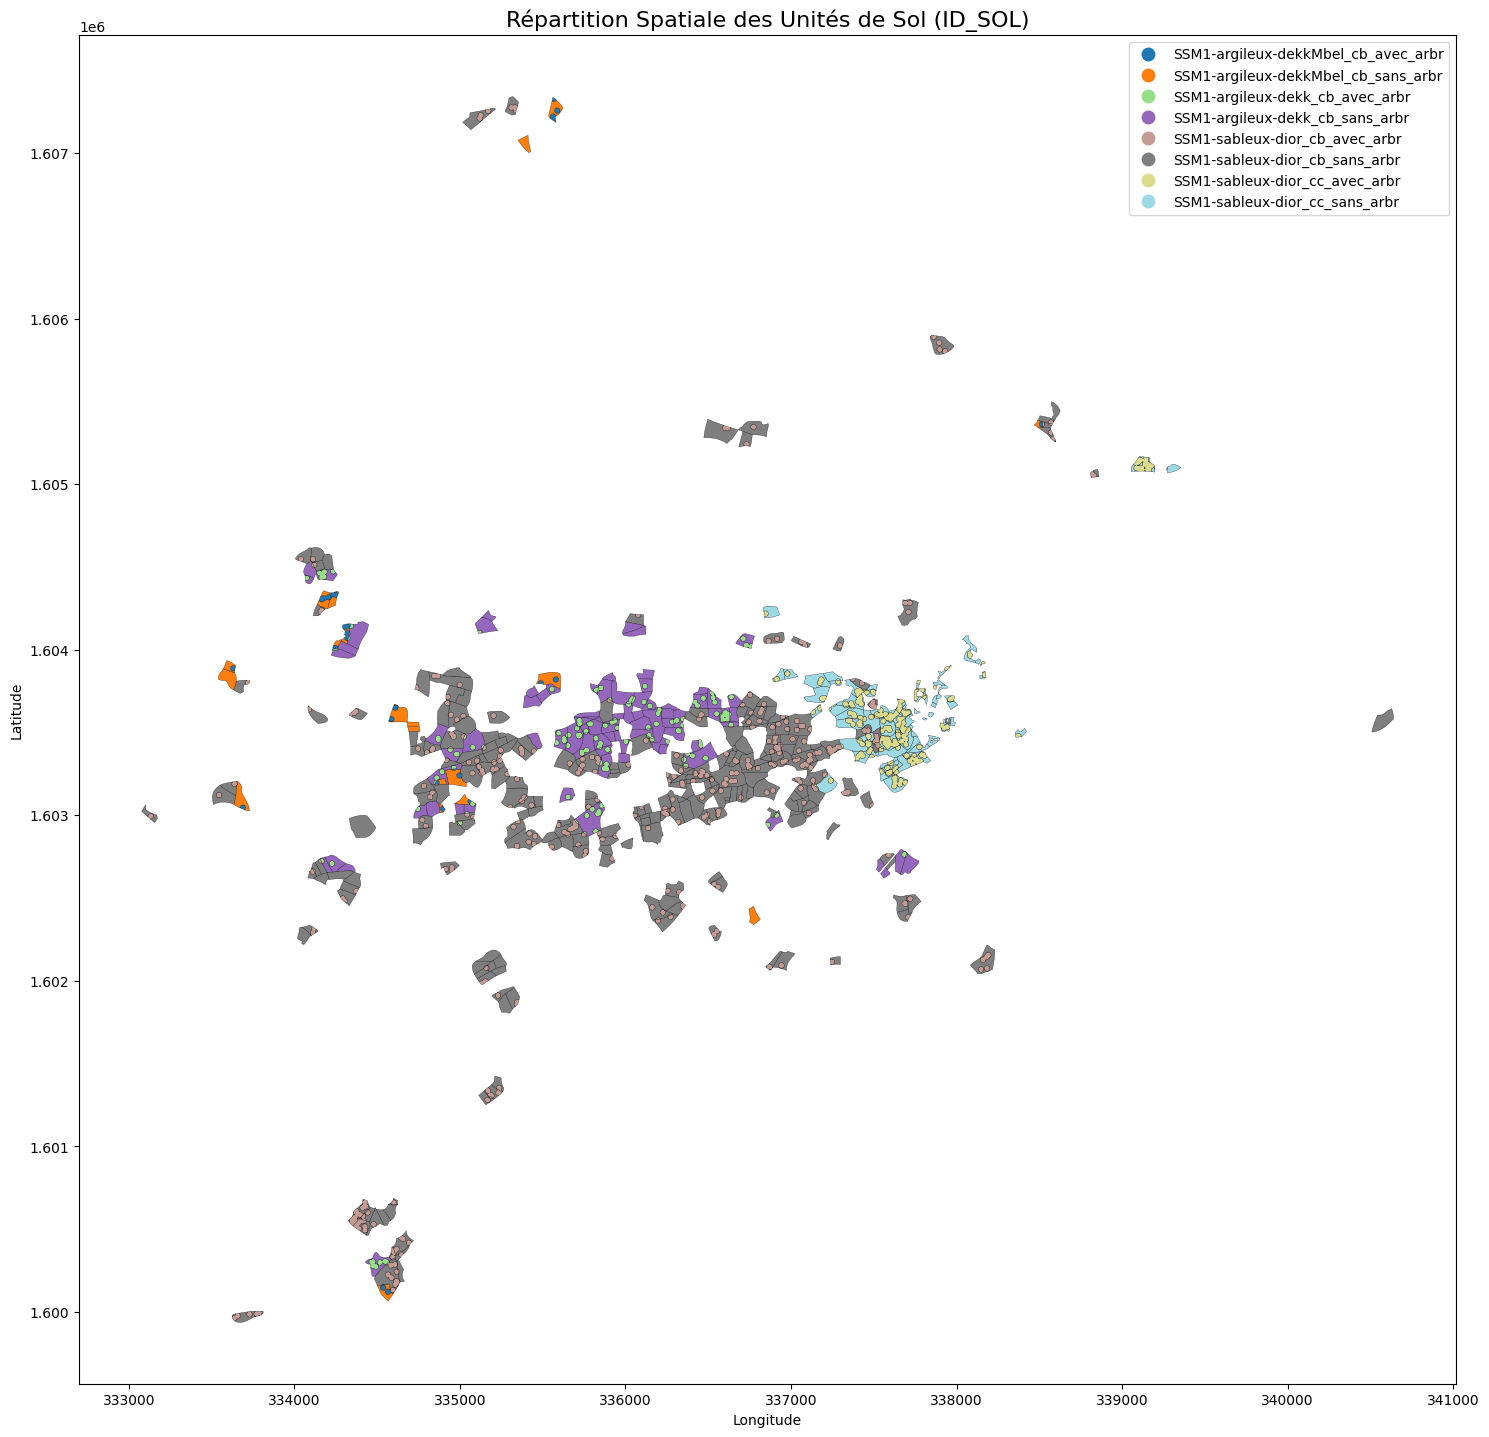

In [12]:
# --- VISUALISATION ---

fig, ax = plt.subplots(1, 1, figsize=(15, 15))

gdf_final.plot(
    column='ID_SOL', # Colonne utilisée pour la coloration
    ax=ax,
    legend=True,     # Afficher la légende
    cmap='tab20',      # Palette de couleurs adaptées aux catégories
    edgecolor='black', # Couleur des bordures des parcelles
    linewidth=0.2
)

# Améliorer l'affichage
ax.set_title("Répartition Spatiale des Unités de Sol (ID_SOL)", fontsize=16)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

In [13]:
# --- FUSION (DISSOLVE) ---
print(f"Nombre de polygones avant la fusion : {len(gdf_final)}")

# Fusionner les polygones en se basant sur la colonne 'ZONE_PEDO'
# aggfunc='first' signifie que pour les autres colonnes, on garde la première valeur rencontrée
# (ce qui est correct ici car elles sont toutes identiques pour une même ZONE_PEDO)
gdf_fusion = gdf_final.dissolve(by='ZONE_PEDO', aggfunc='first').reset_index()

# --- VÉRIFICATION ---
print(f"Nombre de polygones après la fusion : {len(gdf_fusion)}")
print("\n✅ Fusion des polygones terminée.")
print("Aperçu du GeoDataFrame fusionné :")
display(gdf_fusion.head())

Nombre de polygones avant la fusion : 739
Nombre de polygones après la fusion : 8

✅ Fusion des polygones terminée.
Aperçu du GeoDataFrame fusionné :


,ZONE_PEDO,geometry,ID_SOL,ID_ZH,STU_DOM,PIRM,CSTRU,PRO,P1,P2,...,HPFP1,HPFP2,RUPRH1,RUPRH2,KSAT1,KSAT2,EG1,EG2,CAL1,CAL2
0,dekkMbel_cb_avec_arbr,"MULTIPOLYGON (((334579.446 1600113.015, 334578...",SSM1-argileux-dekkMbel_cb_avec_arbr,SSM1,argileux,420.24,0.5,60,30,60,...,9.113581,9.235677,32.438357,32.540670,322.74,242.055,0,0,0,0
1,dekkMbel_cb_sans_arbr,"MULTIPOLYGON (((334520.634 1600115.406, 334515...",SSM1-argileux-dekkMbel_cb_sans_arbr,SSM1,argileux,348.00,0.5,60,30,60,...,8.976415,9.353365,31.926052,32.738577,296.28,222.210,0,0,0,0
2,dekk_cb_avec_arbr,"MULTIPOLYGON (((334502.005 1600260.324, 334500...",SSM1-argileux-dekk_cb_avec_arbr,SSM1,argileux,420.24,0.5,60,30,60,...,8.657769,8.797480,30.489314,30.789434,322.74,242.055,0,0,0,0
3,dekk_cb_sans_arbr,"MULTIPOLYGON (((334459.514 1600286.128, 334460...",SSM1-argileux-dekk_cb_sans_arbr,SSM1,argileux,348.00,0.5,60,30,60,...,8.763053,8.867642,31.033094,31.073014,296.28,222.210,0,0,0,0
4,dior_cb_avec_arbr,"MULTIPOLYGON (((333645.574 1599948.217, 333644...",SSM1-sableux-dior_cb_avec_arbr,SSM1,sableux,840.48,0.5,60,30,60,...,8.677742,8.947725,30.514047,31.181659,674.64,505.980,0,0,0,0


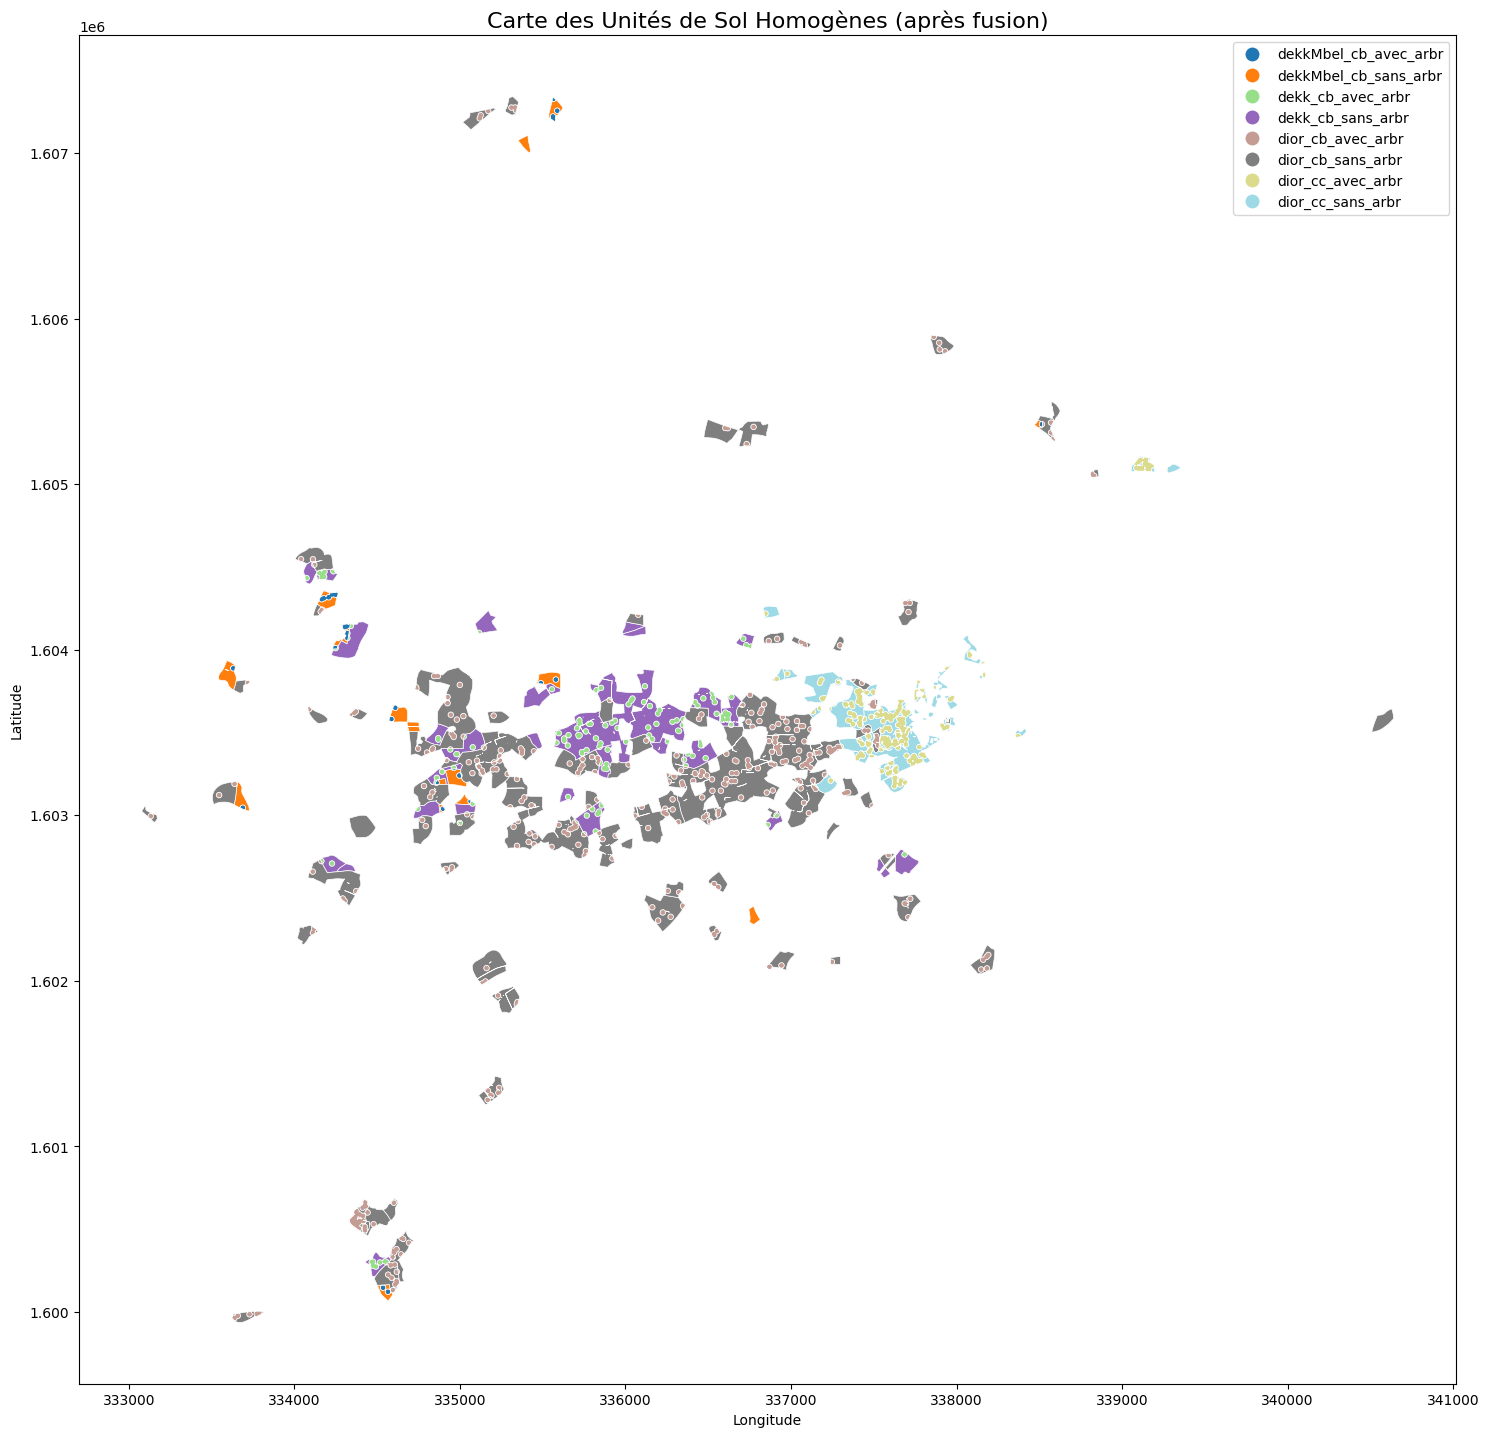

In [14]:
# --- VISUALISATION APRÈS FUSION ---

fig, ax = plt.subplots(1, 1, figsize=(15, 15))

gdf_fusion.plot(
    column='ZONE_PEDO', # On colore selon la ZONE_PEDO qui a servi à la fusion
    ax=ax,
    legend=True,
    cmap='tab20',
    edgecolor='white', # Bordure blanche pour mieux voir les polygones fusionnés
    linewidth=0.5
)

# Améliorer l'affichage
ax.set_title("Carte des Unités de Sol Homogènes (après fusion)", fontsize=16)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

In [15]:
# S'assurer que le dossier de destination existe
output_shapefile_path.parent.mkdir(parents=True, exist_ok=True)

# Sauvegarder le GeoDataFrame fusionné au format Shapefile
gdf_fusion.to_file(
    output_shapefile_path, 
    driver='ESRI Shapefile',
    encoding='utf-8'
)

print("✅ Shapefile final 'typeDeSolParZH.shp' sauvegardé avec succès.")
print(f"   -> Emplacement : {output_shapefile_path}")

✅ Shapefile final 'typeDeSolParZH.shp' sauvegardé avec succès.
   -> Emplacement : C:\Users\Cheikhou\Desktop\Ferlo_Sine\maelia-data-diohine-v1\includes_sassemeV1\modeleCommun\typesDeSol\typeDeSolParZH.shp
